# Gender Classification with PyTorch

This notebook is fully self-contained for VS Code Jupyter mode. Run the cells from top to bottom.

In [1]:
import copy
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    EfficientNet_B2_Weights,
    EfficientNet_B3_Weights,
    MobileNet_V2_Weights,
    ResNet50_Weights,
    efficientnet_b0,
    efficientnet_b2,
    efficientnet_b3,
    mobilenet_v2,
    resnet50,
)

In [ ]:
# Configuration
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

DATA_DIR = Path("dataset")
MODEL_PATH = ARTIFACTS_DIR / "best_model.pth"
MODEL_ARCHITECTURE = "mobilenet_v2"
IMAGE_SIZE = 128
BATCH_SIZE = 16
STAGE1_EPOCHS = 1
STAGE2_EPOCHS = 3
LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0
NUM_WORKERS = 2
PATIENCE = 2
LOG_INTERVAL = 200
USE_WEIGHTED_SAMPLER = False
CLASS_NAMES = ["female", "male"]

In [3]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device


def resolve_split_dirs(data_dir):
    train_dir = data_dir / "train"
    val_dir = data_dir / "val"
    if train_dir.exists() and val_dir.exists():
        return train_dir, val_dir

    train_dir = data_dir / "Training"
    val_dir = data_dir / "Validation"
    if train_dir.exists() and val_dir.exists():
        return train_dir, val_dir

    raise FileNotFoundError(
        "Dataset folders not found. Expected train/val or Training/Validation."
    )


def build_transforms(image_size=IMAGE_SIZE):
    train_transform = transforms.Compose(
        [
            transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=12),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )

    val_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )
    return train_transform, val_transform


def create_datasets(data_dir, image_size=IMAGE_SIZE):
    train_dir, val_dir = resolve_split_dirs(data_dir)
    train_transform, val_transform = build_transforms(image_size)

    train_dataset = datasets.ImageFolder(str(train_dir), transform=train_transform)
    val_dataset = datasets.ImageFolder(str(val_dir), transform=val_transform)

    if sorted(train_dataset.classes) != sorted(CLASS_NAMES):
        raise ValueError(
            f"Expected classes {CLASS_NAMES}, but found {train_dataset.classes}"
        )

    return train_dataset, val_dataset


def build_sampler(train_dataset):
    targets = train_dataset.targets
    class_counts = torch.bincount(torch.tensor(targets))
    class_weights = 1.0 / class_counts.float()
    sample_weights = [class_weights[target].item() for target in targets]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


def build_dataloaders(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, use_weighted_sampler=USE_WEIGHTED_SAMPLER):
    train_dataset, val_dataset = create_datasets(data_dir, image_size)
    pin_memory = torch.cuda.is_available()
    sampler = build_sampler(train_dataset) if use_weighted_sampler else None

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=sampler is None,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=num_workers > 0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=num_workers > 0,
    )

    return train_dataset, val_dataset, train_loader, val_loader


def set_trainable_layers(model, architecture, train_backbone):
    if architecture == "mobilenet_v2":
        for param in model.features.parameters():
            param.requires_grad = train_backbone
        for param in model.classifier.parameters():
            param.requires_grad = True
        return

    if architecture.startswith("efficientnet_"):
        for param in model.features.parameters():
            param.requires_grad = train_backbone
        for param in model.classifier.parameters():
            param.requires_grad = True
        return

    if architecture == "resnet50":
        for name, param in model.named_parameters():
            if name.startswith("fc"):
                param.requires_grad = True
            else:
                param.requires_grad = train_backbone
        return


def create_model(architecture=MODEL_ARCHITECTURE, num_classes=2, train_backbone=True, pretrained=True):
    model_builders = {
        "mobilenet_v2": (mobilenet_v2, MobileNet_V2_Weights.DEFAULT),
        "efficientnet_b0": (efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        "efficientnet_b2": (efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
        "efficientnet_b3": (efficientnet_b3, EfficientNet_B3_Weights.DEFAULT),
        "resnet50": (resnet50, ResNet50_Weights.DEFAULT),
    }

    if architecture not in model_builders:
        raise ValueError(f"Unsupported architecture: {architecture}")

    builder, default_weights = model_builders[architecture]
    model = builder(weights=default_weights if pretrained else None)

    if architecture == "mobilenet_v2":
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif architecture.startswith("efficientnet_"):
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif architecture == "resnet50":
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    set_trainable_layers(model, architecture, train_backbone)
    return model


def save_checkpoint(model, class_to_idx, architecture, image_size, save_path):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "image_size": image_size,
        "class_names": CLASS_NAMES,
        "architecture": architecture,
    }
    torch.save(checkpoint, save_path)


def run_epoch(model, dataloader, criterion, optimizer, device, is_training, scaler=None, log_interval=0):
    model.train() if is_training else model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0
    use_amp = scaler is not None and device.type == "cuda"

    context_manager = torch.enable_grad if is_training else torch.no_grad
    with context_manager():
        total_batches = len(dataloader)
        for batch_idx, (images, labels) in enumerate(dataloader, start=1):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_training:
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            predictions = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predictions == labels).sum().item()
            total_samples += batch_size

            if is_training and log_interval > 0 and (
                batch_idx % log_interval == 0 or batch_idx == total_batches
            ):
                avg_loss = running_loss / total_samples
                avg_acc = running_correct / total_samples
                print(
                    f"  Batch [{batch_idx}/{total_batches}] | Train Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f}"
                )

    epoch_loss = running_loss / total_samples
    epoch_accuracy = running_correct / total_samples
    return epoch_loss, epoch_accuracy


def run_training_stage(
    model,
    architecture,
    stage_name,
    train_loader,
    val_loader,
    device,
    class_to_idx,
    epochs,
    learning_rate,
    weight_decay,
    label_smoothing,
    patience,
    save_path,
    image_size,
    history,
    best_val_loss,
    best_model_state,
    log_interval,
    train_backbone,
):
    set_trainable_layers(model, architecture, train_backbone=train_backbone)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(
        (param for param in model.parameters() if param.requires_grad),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None
    epochs_without_improvement = 0

    print(f"{stage_name}: {'full fine-tuning' if train_backbone else 'classifier warm-up'}")

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"{stage_name} | Epoch {epoch}/{epochs} | LR: {current_lr:.6f}")

        train_loss, train_acc = run_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            is_training=True,
            scaler=scaler,
            log_interval=log_interval,
        )
        val_loss, val_acc = run_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            is_training=False,
            scaler=None,
        )

        scheduler.step(val_loss)
        elapsed = time.time() - epoch_start
        print(
            f"{stage_name} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s"
        )

        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            save_checkpoint(model, class_to_idx, architecture, image_size, save_path)
            print(f"Best model saved to: {Path(save_path).resolve()}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered in {stage_name}.")
                break

    return best_val_loss, best_model_state


def train_model(
    data_dir=DATA_DIR,
    architecture=MODEL_ARCHITECTURE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    stage1_epochs=STAGE1_EPOCHS,
    stage2_epochs=STAGE2_EPOCHS,
    learning_rate_stage1=LEARNING_RATE_STAGE1,
    learning_rate_stage2=LEARNING_RATE_STAGE2,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    num_workers=NUM_WORKERS,
    patience=PATIENCE,
    save_path=MODEL_PATH,
    log_interval=LOG_INTERVAL,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
):
    device = get_device()
    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(
        data_dir=data_dir,
        image_size=image_size,
        batch_size=batch_size,
        num_workers=num_workers,
        use_weighted_sampler=use_weighted_sampler,
    )

    model = create_model(
        architecture=architecture,
        num_classes=2,
        train_backbone=False,
        pretrained=True,
    ).to(device)

    class_to_idx = train_dataset.class_to_idx
    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    history = {
        "stage": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    class_counts = torch.bincount(torch.tensor(train_dataset.targets))
    print(f"Architecture: {architecture}")
    print(f"Classes: {list(class_to_idx.keys())}")
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Class counts: {class_counts.tolist()}")
    print(f"Weighted sampler: {use_weighted_sampler}")
    print("-" * 60)

    best_val_loss, best_model_state = run_training_stage(
        model=model,
        architecture=architecture,
        stage_name="Stage 1",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_to_idx=class_to_idx,
        epochs=stage1_epochs,
        learning_rate=learning_rate_stage1,
        weight_decay=weight_decay,
        label_smoothing=label_smoothing,
        patience=patience,
        save_path=save_path,
        image_size=image_size,
        history=history,
        best_val_loss=best_val_loss,
        best_model_state=best_model_state,
        log_interval=log_interval,
        train_backbone=False,
    )

    model.load_state_dict(best_model_state)

    best_val_loss, best_model_state = run_training_stage(
        model=model,
        architecture=architecture,
        stage_name="Stage 2",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_to_idx=class_to_idx,
        epochs=stage2_epochs,
        learning_rate=learning_rate_stage2,
        weight_decay=weight_decay,
        label_smoothing=label_smoothing,
        patience=patience,
        save_path=save_path,
        image_size=image_size,
        history=history,
        best_val_loss=best_val_loss,
        best_model_state=best_model_state,
        log_interval=log_interval,
        train_backbone=True,
    )

    model.load_state_dict(best_model_state)
    save_checkpoint(model, class_to_idx, architecture, image_size, save_path)
    print("-" * 60)
    print(f"Training finished. Best validation loss: {best_val_loss:.4f}")
    print(f"Final best model saved to: {Path(save_path).resolve()}")
    return model, history, Path(save_path)


def load_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    architecture = checkpoint.get("architecture", "mobilenet_v2")
    class_names = checkpoint.get("class_names", CLASS_NAMES)
    model = create_model(
        architecture=architecture,
        num_classes=len(class_names),
        train_backbone=True,
        pretrained=False,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint


def build_predict_transform(image_size):
    return transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )


def predict_image(image_path, model_path=MODEL_PATH):
    device = get_device()
    model, checkpoint = load_model(model_path, device)

    image_size = checkpoint.get("image_size", IMAGE_SIZE)
    class_to_idx = checkpoint.get(
        "class_to_idx",
        {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)},
    )
    idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

    transform = build_predict_transform(image_size)
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = idx_to_class[predicted_idx.item()].lower()
    label = "Male" if predicted_class == "male" else "Female"
    return label, confidence.item()

In [4]:
device = get_device()
train_dir, val_dir = resolve_split_dirs(DATA_DIR)
train_dataset, val_dataset = create_datasets(DATA_DIR, image_size=IMAGE_SIZE)

print(f"Train folder: {train_dir}")
print(f"Validation folder: {val_dir}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Using GPU: NVIDIA GeForce GTX 1650
Train folder: dataset\Training
Validation folder: dataset\Validation
Train samples: 47009
Validation samples: 11649
Classes: ['female', 'male']


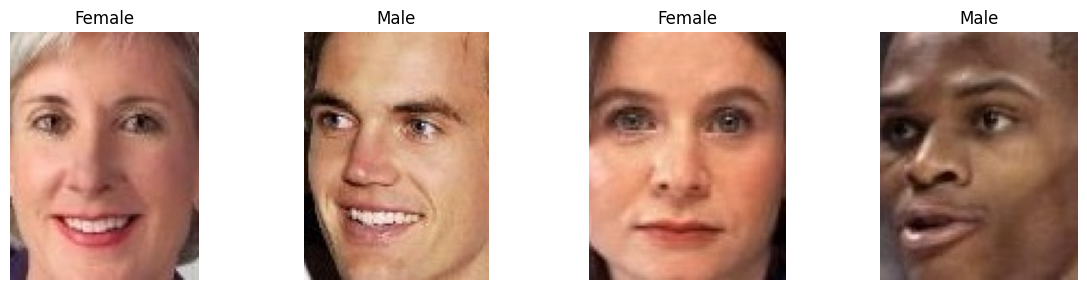

In [6]:
import random
female_samples = [s for s in train_dataset.samples if train_dataset.classes[s[1]] == "female"]
male_samples = [s for s in train_dataset.samples if train_dataset.classes[s[1]] == "male"]

selected = random.sample(female_samples, 2) + random.sample(male_samples, 2)
random.shuffle(selected)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, (image_path, label_index) in zip(axes, selected):
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(train_dataset.classes[label_index].title())
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Train the model
model, history, saved_model_path = train_model(
    data_dir=DATA_DIR,
    architecture=MODEL_ARCHITECTURE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    stage1_epochs=STAGE1_EPOCHS,
    stage2_epochs=STAGE2_EPOCHS,
    learning_rate_stage1=LEARNING_RATE_STAGE1,
    learning_rate_stage2=LEARNING_RATE_STAGE2,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    num_workers=NUM_WORKERS,
    patience=PATIENCE,
    save_path=MODEL_PATH,
    log_interval=LOG_INTERVAL,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
)

print(f"Saved model: {saved_model_path.resolve()}")

Using GPU: NVIDIA GeForce GTX 1650
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:03<00:00, 10.3MB/s]


Architecture: efficientnet_b2
Classes: ['female', 'male']
Training samples: 47009
Validation samples: 11649
Class counts: [23243, 23766]
Weighted sampler: True
------------------------------------------------------------
Stage 1: classifier warm-up
Stage 1 | Epoch 1/4 | LR: 0.000500


In [ ]:
# Plot training history
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Pick one image for prediction
sample_image_path = Path(val_dataset.samples[0][0])
sample_image_path

In [ ]:
image = Image.open(sample_image_path).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

label, confidence = predict_image(sample_image_path, model_path=saved_model_path)
print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")